In [1]:
import torch
import numpy as np
import random
import pandas as pd
from torch import nn
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx
from sklearn.manifold import TSNE
from src.models import OneLayerGCN, TwoLayerGCN, ThreeLayerGCN, FourLayerGCN, FiveLayerGCN
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
image_dir = Path('images/')
image_dir.mkdir(exist_ok=True)
seed = 42

def set_seed(seed):
    """Фиксация seed для воспроизводимости"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.set_deterministic_debug_mode(1)
    
set_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

В качестве датасета используется датасет с графом из torch_geometric - Zachary's Karate Club, где каждый узел - участник клуба, а ребро - социальная связь между двумя участниками клуба.

In [2]:
dataset = KarateClub()
data = dataset[0].to(device)

In [3]:
print(f'Количество узлов: {data.num_nodes}')

Количество узлов: 34


In [4]:
print(f'Форма x: {data.x.shape}')
print(f'Тип: {data.x.dtype}') 
print(f'x:\n{data.x}')

Форма x: torch.Size([34, 34])
Тип: torch.float32
x:
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])


In [5]:
print(f'Форма y: {data.y.shape}')
print(f'Тип: {data.y.dtype}') 
print(f'y:\n{data.y}')

Форма y: torch.Size([34])
Тип: torch.int64
y:
tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])


In [39]:
print(f'Количество классов: {dataset.num_classes}')
unique, counts = torch.unique(data.y, return_counts=True)
print(unique, counts)
total = data.y.numel()
for val, cnt in zip(unique, counts):
    percentage = cnt / total * 100
    print(f"  Значение {val.item():.0f}: {percentage:.2f}% ({cnt} элементов)")

Количество классов: 4
tensor([0, 1, 2, 3]) tensor([13, 12,  4,  5])
  Значение 0: 38.24% (13 элементов)
  Значение 1: 35.29% (12 элементов)
  Значение 2: 11.76% (4 элементов)
  Значение 3: 14.71% (5 элементов)


In [7]:
print(f'Маска обучающих данных: \n{data.train_mask}')
print(f'Количество обучающих примеров: {data.train_mask.sum()}')
print(f'Классы обучающих примеров: {data.y[data.train_mask]}')

Маска обучающих данных: 
tensor([ True, False, False, False,  True, False, False, False,  True, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False, False, False, False,
        False, False, False, False])
Количество обучающих примеров: 4
Классы обучающих примеров: tensor([1, 3, 0, 2])


In [8]:
print(f'Форма edge_index: {data.edge_index.shape}')
print(f'Тип: {data.edge_index.dtype}') 
print(f'edge_index:\n{data.edge_index}')

Форма edge_index: torch.Size([2, 156])
Тип: torch.int64
edge_index:
tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
          3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
          7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
         13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
         21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
         27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
        [ 1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 17, 19, 21, 31,  0,  2,
          3,  7, 13, 17, 19, 21, 30,  0,  1,  3,  7,  8,  9, 13, 27, 28, 32,  0,
          1,  2,  7, 12, 13,  0,  6, 10,  0,  6, 10, 16,  0,  4,

Всего 34 узла и 156 направленных ребер.

Всего четыре класса: 0, 1, 2, 3. При этом они не особо сбалансированы.

В обучающих данных только четыре узла, каждый соответствует одному из четырех классов.

Признаками (data.x) являются one-hot вектора с 1 на позициии, соответствующей номеру узла.

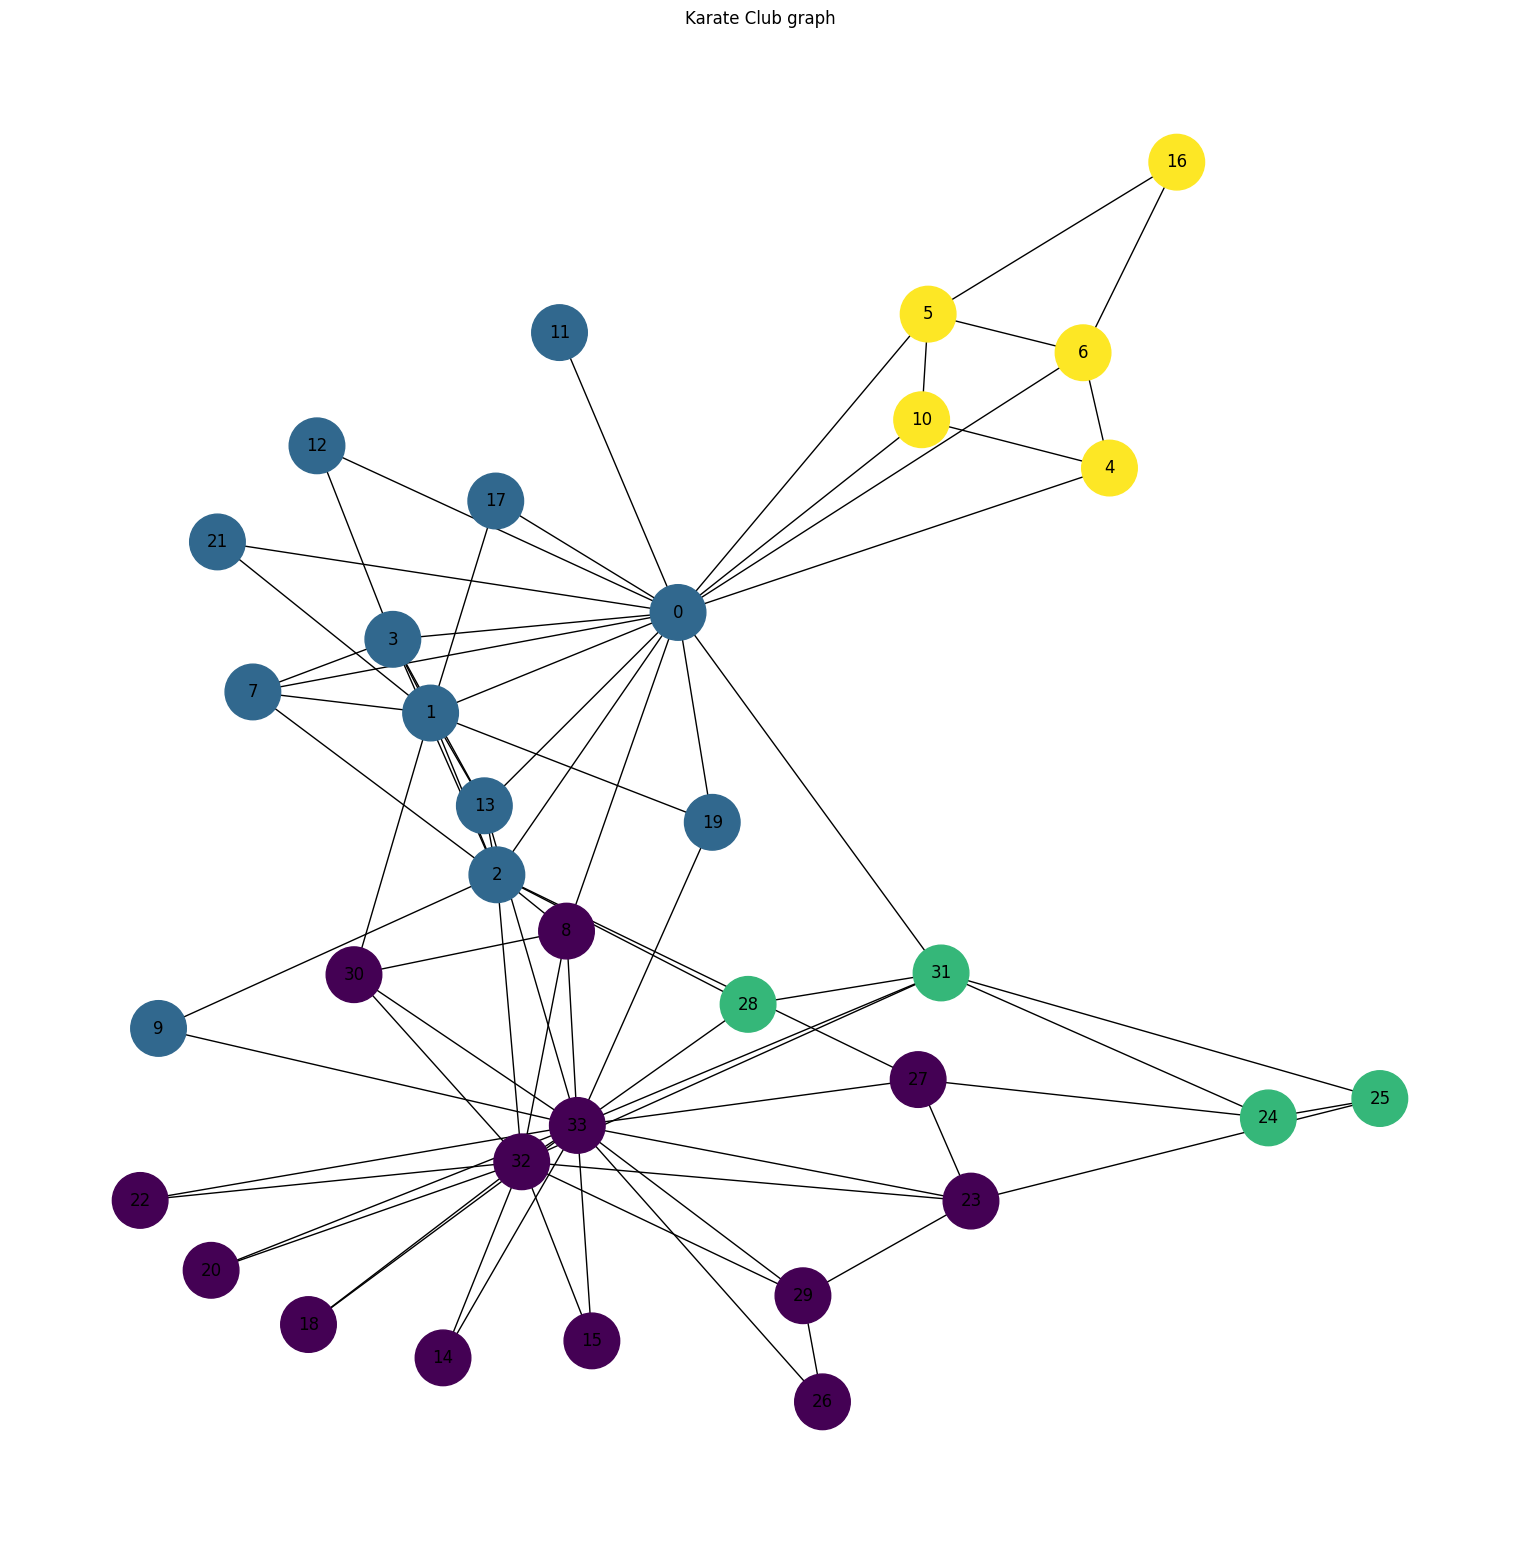

In [9]:
G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G, seed=seed)
nx.draw(G, pos, node_color=data.y, node_size=1600, with_labels=True)
plt.title('Karate Club graph')
plt.savefig(image_dir / 'karate_club_graph.png')
plt.show()

In [10]:
edges = {}
for ed in data.edge_index[0]:
    edges[int(ed)] = edges.get(int(ed), 0) + 1
for ed in edges:
    edges[ed] //= 2

print('Средняя степень узлов графа:', sum(edges.values()) / len(edges.values()))
print('Плотность графа:', sum(edges.values()) / data.num_nodes * 2 / (data.num_nodes - 1))

Средняя степень узлов графа: 2.1176470588235294
Плотность графа: 0.12834224598930483


In [11]:
def train(model, epochs=200):
    """Обучение модели"""
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
    return model

def evaluate(model):
    """Расчет точности модели на не обучающих данных"""
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        inverse_mask = ~data.train_mask

        correct = (pred[inverse_mask] == data.y[inverse_mask]).sum().item()
        total = inverse_mask.sum().item()

        return correct / total if total > 0 else 0.0

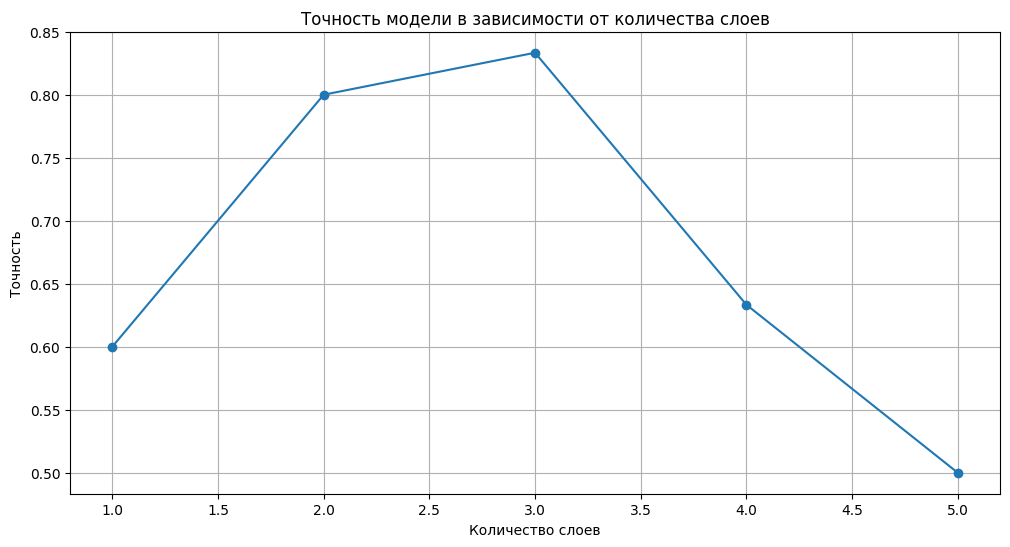

In [12]:
num_layers = [i for i in range(1, 6)]

num_features = data.num_features
hidden = 16
num_classes = dataset.num_classes

model1 = OneLayerGCN(in_channels=num_features, out_channels=num_classes).to(device)
model2 = TwoLayerGCN(in_channels=num_features, hidden_channels=hidden, out_channels=num_classes).to(device)
model3 = ThreeLayerGCN(in_channels=num_features, hidden_channels1=hidden, hidden_channels2=hidden, out_channels=num_classes).to(device)
model4 = FourLayerGCN(in_channels=num_features, hidden_channels1=hidden, hidden_channels2=hidden, hidden_channels3=hidden, out_channels=num_classes).to(device)
model5 = FiveLayerGCN(in_channels=num_features, hidden_channels1=hidden, hidden_channels2=hidden, hidden_channels3=hidden, hidden_channels4=hidden, out_channels=num_classes).to(device)

model1 = train(model1)
model2 = train(model2)
model3 = train(model3)
model4 = train(model4)
model5 = train(model5)

acc = [evaluate(model1), evaluate(model2), evaluate(model3), evaluate(model4), evaluate(model5)]

plt.figure(figsize=(12, 6))
plt.plot(num_layers, acc, marker='o')
plt.xlabel('Количество слоев')
plt.ylabel('Точность')
plt.title('Тoчность модели в зависимости от количества слоев')
plt.grid(True)
plt.savefig(image_dir / 'accuracy_vs_layer_number.png')
plt.show()

In [13]:
accuracies = pd.Series({f'{i + 1} layer GCN': acc[i] for i in range(len(acc))}, name='accuracy')
accuracies

1 layer GCN    0.600000
2 layer GCN    0.800000
3 layer GCN    0.833333
4 layer GCN    0.633333
5 layer GCN    0.500000
Name: accuracy, dtype: float64

Эксперимент заключается в обучении пяти моделей, каждая из которых содержит графовые сверточные слои, и сравнении их точности.

Как видно из графика, при увеличении количества слоев до 3 штук точности нейросети растет (0.60 -> 0.80 -> 0.83), но резко падает при дальнейшем увеличении до 4 и 5 слоев (0.83 -> 0.63 -> 0.50). Это можено объяснить эффектом чрезмерного сглаживаения (oversmoothing), которым обладают сверточные графовые сети, когда при добавлении большего числа слоев узлы графа становятся неразличимыми или слабо различимыми между собой.

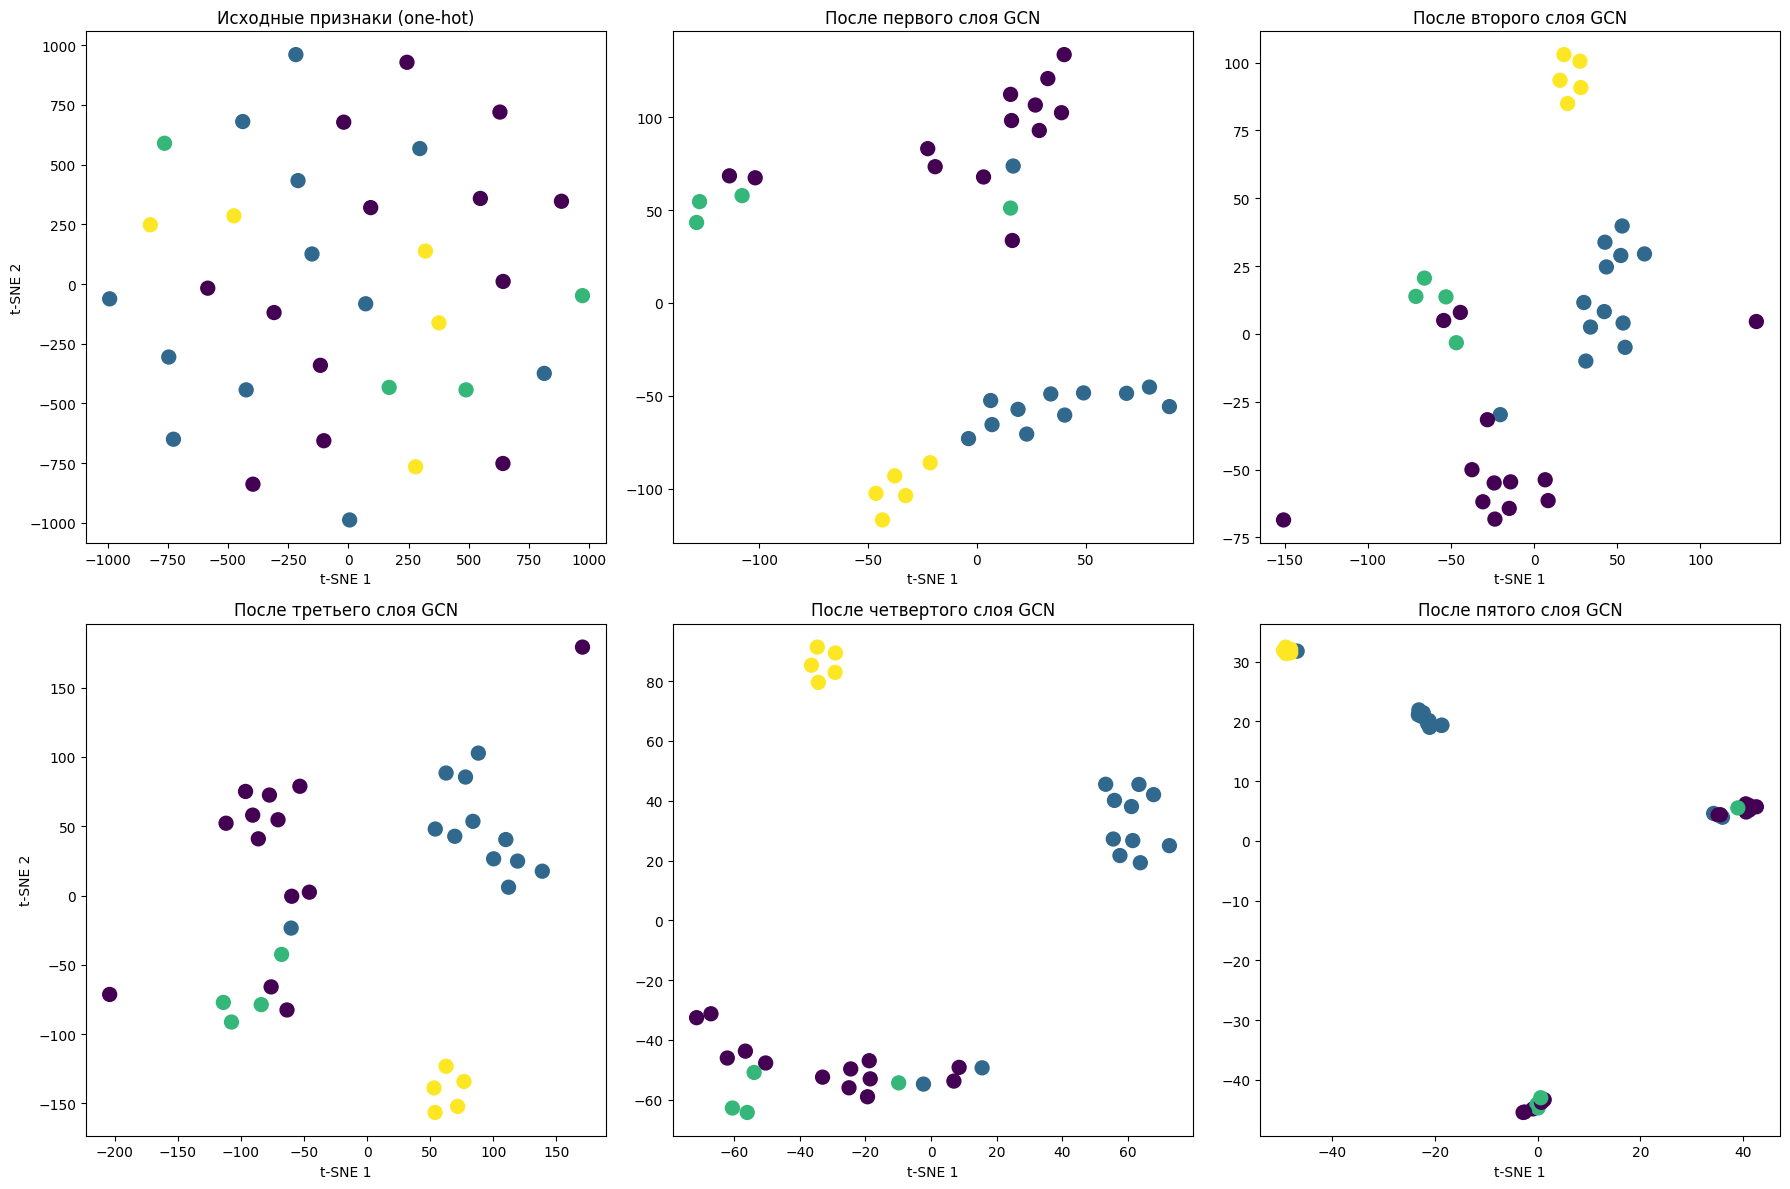

In [20]:
model1.eval()
with torch.no_grad():
    out = model1(data.x, data.edge_index)

    original = data.x.numpy()
    conv1 = model1.embeddings['after_conv1'].numpy()

model2.eval()
with torch.no_grad():
    out = model2(data.x, data.edge_index)

    conv2 = model2.embeddings['after_conv2'].numpy()

model3.eval()
with torch.no_grad():
    out = model3(data.x, data.edge_index)

    conv3 = model3.embeddings['after_conv3'].numpy()

model4.eval()
with torch.no_grad():
    out = model4(data.x, data.edge_index)

    conv4 = model4.embeddings['after_conv4'].numpy()
    
model5.eval()
with torch.no_grad():
    out = model5(data.x, data.edge_index)

    conv5 = model5.embeddings['after_conv5'].numpy()

tsne = TSNE(n_components=2, random_state=seed, perplexity=5)

orig_tsne = tsne.fit_transform(original)
conv1_tsne = tsne.fit_transform(conv1)
conv2_tsne = tsne.fit_transform(conv2)
conv3_tsne = tsne.fit_transform(conv3)
conv4_tsne = tsne.fit_transform(conv4)
conv5_tsne = tsne.fit_transform(conv5)


fig, axes = plt.subplots(2, 3, figsize=(18, 12))

scatter1 = axes[0, 0].scatter(orig_tsne[:, 0], orig_tsne[:, 1],
                           c=data.y, cmap='viridis', s=100)
axes[0, 0].set_title('Исходные признаки (one-hot)')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')

scatter2 = axes[0, 1].scatter(conv1_tsne[:, 0], conv1_tsne[:, 1],
                           c=data.y, cmap='viridis', s=100)
axes[0, 1].set_title('После первого слоя GCN')
axes[0, 1].set_xlabel('t-SNE 1')

scatter3 = axes[0, 2].scatter(conv2_tsne[:, 0], conv2_tsne[:, 1],
                           c=data.y, cmap='viridis', s=100)
axes[0, 2].set_title('После второго слоя GCN')
axes[0, 2].set_xlabel('t-SNE 1')

scatter4 = axes[1, 0].scatter(conv3_tsne[:, 0], conv3_tsne[:, 1],
                           c=data.y, cmap='viridis', s=100)
axes[1, 0].set_title('После третьего слоя GCN')
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')

scatter5 = axes[1, 1].scatter(conv4_tsne[:, 0], conv4_tsne[:, 1],
                           c=data.y, cmap='viridis', s=100)
axes[1, 1].set_title('После четвертого слоя GCN')
axes[1, 1].set_xlabel('t-SNE 1')

scatter6 = axes[1, 2].scatter(conv5_tsne[:, 0], conv5_tsne[:, 1],
                           c=data.y, cmap='viridis', s=100)
axes[1, 2].set_title('После пятого слоя GCN')
axes[1, 2].set_xlabel('t-SNE 1')

plt.tight_layout()
plt.savefig(image_dir / 'features_vs_layer_number.png')
plt.show()

Для визуализации признаковых представлений использовался алгоритм понижения размености T-SNE. На первом рисунке видно, что узлы графа в исходном признаковом пространстве никак не сгруппированы, что меняется с применением слоев графовой свертки. При этом также видно, что после четвертого слоя узлы начинают сильнее кучковаться, а после пятого иметь практически одинаковые признаковые представления. 

In [28]:
def experiment():
    model1 = OneLayerGCN(in_channels=num_features, out_channels=num_classes).to(device)
    model2 = TwoLayerGCN(in_channels=num_features, hidden_channels=hidden, out_channels=num_classes).to(device)
    model3 = ThreeLayerGCN(in_channels=num_features, hidden_channels1=hidden, hidden_channels2=hidden, out_channels=num_classes).to(device)
    model4 = FourLayerGCN(in_channels=num_features, hidden_channels1=hidden, hidden_channels2=hidden, hidden_channels3=hidden, out_channels=num_classes).to(device)
    model5 = FiveLayerGCN(in_channels=num_features, hidden_channels1=hidden, hidden_channels2=hidden, hidden_channels3=hidden, hidden_channels4=hidden, out_channels=num_classes).to(device)
    
    model1 = train(model1)
    model2 = train(model2)
    model3 = train(model3)
    model4 = train(model4)
    model5 = train(model5)
    
    acc = [evaluate(model1), evaluate(model2), evaluate(model3), evaluate(model4), evaluate(model5)]
    return acc
    

In [29]:
accs = {f'{i + 1} layer GCN': [] for i in range(5)}
for i in range(30):
    set_seed(i)
    acc = experiment()
    for j in range(5):
        accs[f'{j + 1} layer GCN'].append(acc[j])

In [32]:
consistency_results = pd.DataFrame({'mean': [np.mean(v) for v in accs.values()],
                                   'std': [np.std(v) for v in accs.values()]}, index=accs.keys())
consistency_results

,mean,std
1 layer GCN,0.601111,0.005984
2 layer GCN,0.767778,0.018224
3 layer GCN,0.733333,0.055109
4 layer GCN,0.681111,0.079668
5 layer GCN,0.521111,0.112376


Было проведено 30 экспериментов обучения моделей и посчета точности предсказаний на тестовых узлах графа с разными seed. Проверка устойчивости обучения моделей показала, что наиболее усточивой моделью является модель с одним слоем графовой свертки с наименьшим стандартным отклонением, наиболее плохая модель - модель с пятью слоями, наиболее удачная и устойчивая модель - модель с двумя слоями графовой свертки - обладает наибольшей точностью (0.77) на данном датасете и относительной устойчивостью. 

Трехслойная модель также показывает в среднем неплохое качество, но намного более неустойчива, чем двухслойная версия, хотя в результатах, представленных выше, она наоборот вышла самой удачной.